# Generalisation

### 2025-09-09

**Abstract**: This lecture will cover generalisation in machine
learning.

$$
$$

<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!---->
<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!-- The last names to be defined. Should be defined entirely in terms of macros from above-->
<!--

-->

## ML Foundations Course Notebook Setup

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We install some bespoke codes for creating and saving plots as well as
loading data sets.

In [1]:
%%capture
%pip install notutils
%pip install pods
%pip install mlai

In [2]:
import notutils
import pods
import mlai
import mlai.plot as plot

In [3]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})

<!--setupplotcode{import seaborn as sns
sns.set_style('darkgrid')
sns.set_context('paper')
sns.set_palette('colorblind')}-->

## Olympic Marathon Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_datasets/includes/olympic-marathon-data.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_datasets/includes/olympic-marathon-data.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

<table>
<tr>
<td width="70%">

-   Gold medal times for Olympic Marathon since 1896.
-   Marathons before 1924 didn’t have a standardized distance.
-   Present results using pace per km.
-   In 1904 Marathon was badly organized leading to very slow times.

</td>
<td width="30%">

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//datasets/eliud-kipchoge_berlin_2015.jpg" style="width:100%">
<small>Image from [Wikimedia
Commons](https://commons.wikimedia.org/wiki/File:Eliud_Kipchoge_in_Berlin_-_2015_(cropped).jpg)</small>

</td>
</tr>
</table>

The first thing we will do is load a standard data set for regression
modelling. The data consists of the pace of Olympic Gold Medal Marathon
winners for the Olympics from 1896 to present. Let’s load in the data
and plot.

In [4]:
%pip install pods

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pods

In [6]:
data = pods.datasets.olympic_marathon_men()
x = data['X']
y = data['Y']

offset = y.mean()
scale = np.sqrt(y.var())
yhat = (y - offset)/scale

In [7]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

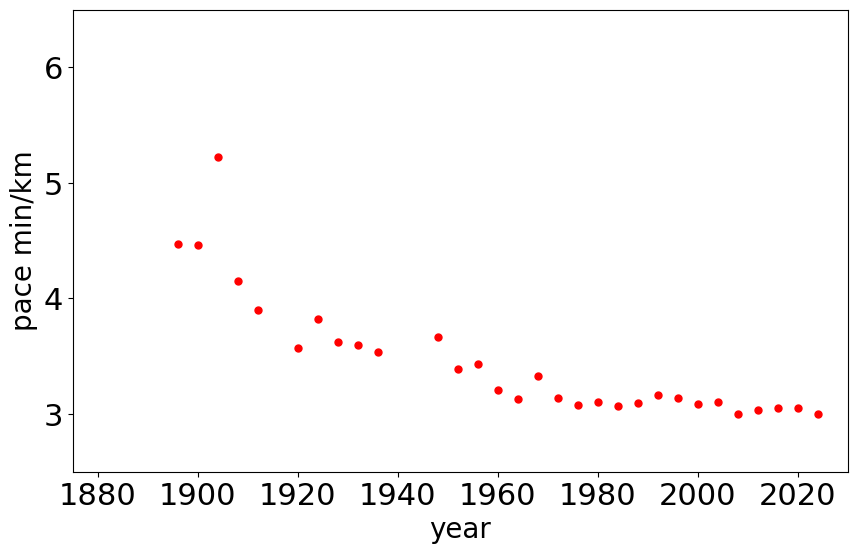

In [8]:
xlim = (1875,2030)
ylim = (2.5, 6.5)

fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

mlai.write_figure(filename='olympic-marathon.svg', 
                  directory='./datasets')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//datasets/olympic-marathon.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Olympic marathon pace times since 1896.</i>

Things to notice about the data include the outlier in 1904, in that
year the Olympics was in St Louis, USA. Organizational problems and
challenges with dust kicked up by the cars following the race meant that
participants got lost, and only very few participants completed. More
recent years see more consistently quick marathons.

## Polynomial Fits to Olympic Marthon Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-polynomial.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-polynomial.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [9]:
import numpy as np
import scipy as sp

Define the polynomial basis function.

In [10]:
import mlai

In [14]:
# %load -n mlai.polynomial
def polynomial(x, num_basis=4, data_limits=[-1., 1.]):
    "Polynomial basis"
    centre = data_limits[0]/2. + data_limits[1]/2.
    span = data_limits[1] - data_limits[0]
    z = np.asarray(x, dtype=float) - centre
    z = 2*z/span
    Phi = np.zeros((x.shape[0], num_basis))
    for i in range(num_basis):
        Phi[:, i:i+1] = z**i
    return Phi

Now we include the solution for the linear regression through
QR-decomposition.

In [15]:
def basis_fit(Phi, y):
    "Use QR decomposition to fit the basis."""
    Q, R = np.linalg.qr(Phi)
    return sp.linalg.solve_triangular(R, Q.T@y) 

## Linear Fit

In [16]:
poly_args = {'num_basis':2, # two basis functions (1 and x)
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
w = basis_fit(Phi, y)

Now we make some predictions for the fit.

In [17]:
x_pred = np.linspace(xlim[0], xlim[1], 400)[:, np.newaxis]
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@w

In [18]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

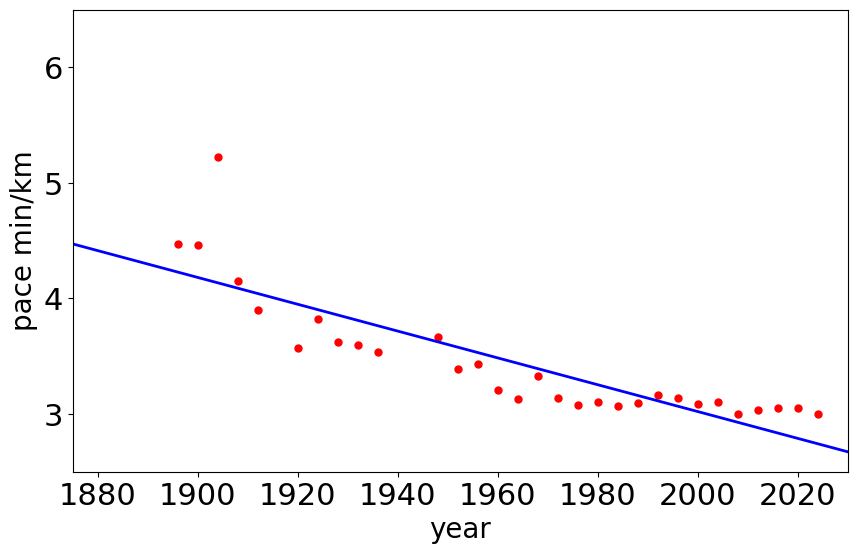

In [19]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-polynomial-2.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-polynomial-2.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 1-degree polynomial (a linear model) to the Olympic
marathon data.</i>

## Cubic Fit

In [20]:
poly_args = {'num_basis':4, # four basis: 1, x, x^2, x^3
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
w = basis_fit(Phi, y)

In [21]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@w

In [22]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

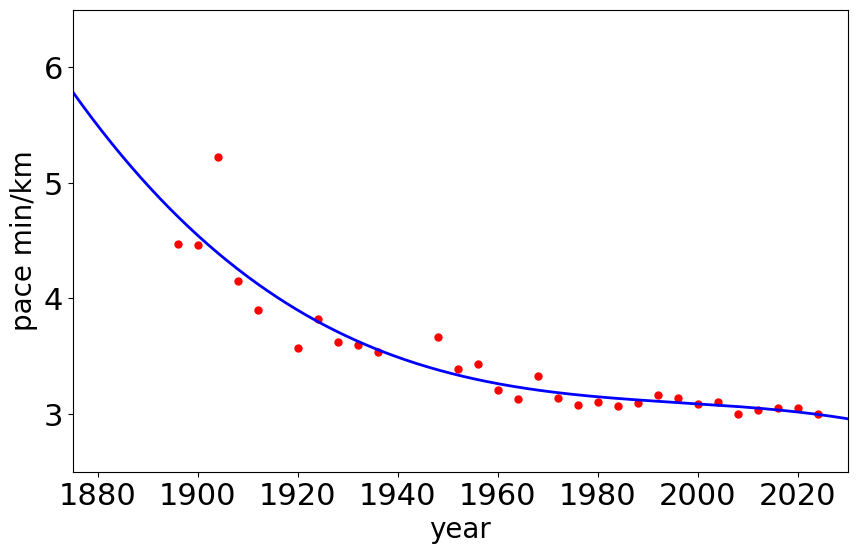

In [23]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-polynomial-4.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-polynomial-4.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 3-degree polynomial (a cubic model) to the Olympic
marathon data.</i>

## 9th Degree Polynomial Fit

Now we’ll try a 9th degree polynomial fit to the data.

In [24]:
poly_args = {'num_basis':10, # basis up to x^9
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
w = basis_fit(Phi, y)

In [25]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@w

In [26]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

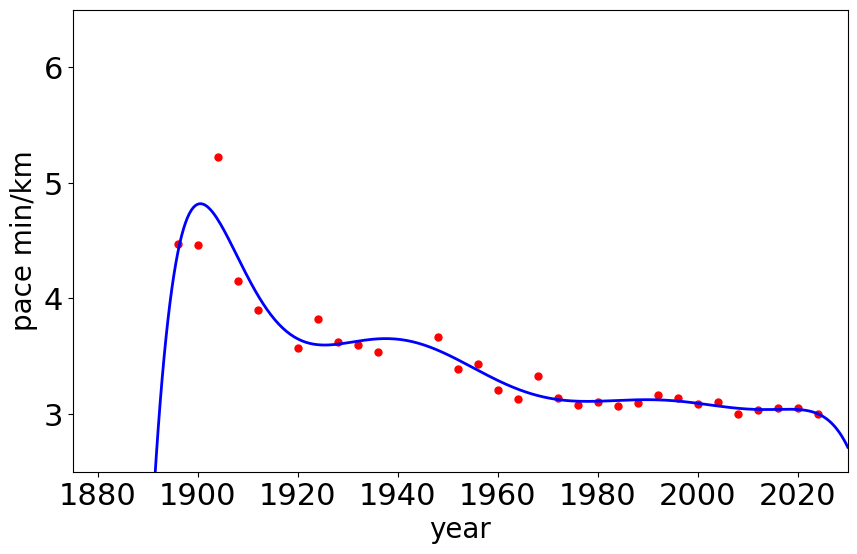

In [27]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-polynomial-10.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-polynomial-10.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 9-degree polynomial to the Olympic marathon
data.</i>

## 16th Degree Polynomial Fit

Now we’ll try a 16th degree polynomial fit to the data.

In [28]:
poly_args = {'num_basis':17, # basis up to x^16
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
w = basis_fit(Phi, y)

In [29]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@w

In [30]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

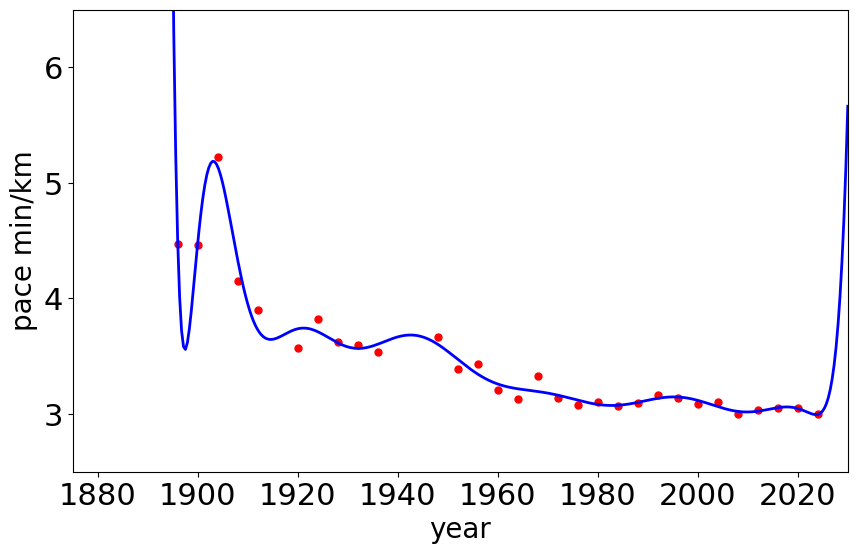

In [31]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-polynomial-17.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-polynomial-17.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 16-degree polynomial to the Olympic marathon
data.</i>

## 28th Degree Polynomial Fit

Now we’ll try a 28th degree polynomial fit to the data.

In [32]:
poly_args = {'num_basis':29, # basis up to x^28
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
w = basis_fit(Phi, y)

In [33]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@w

In [34]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

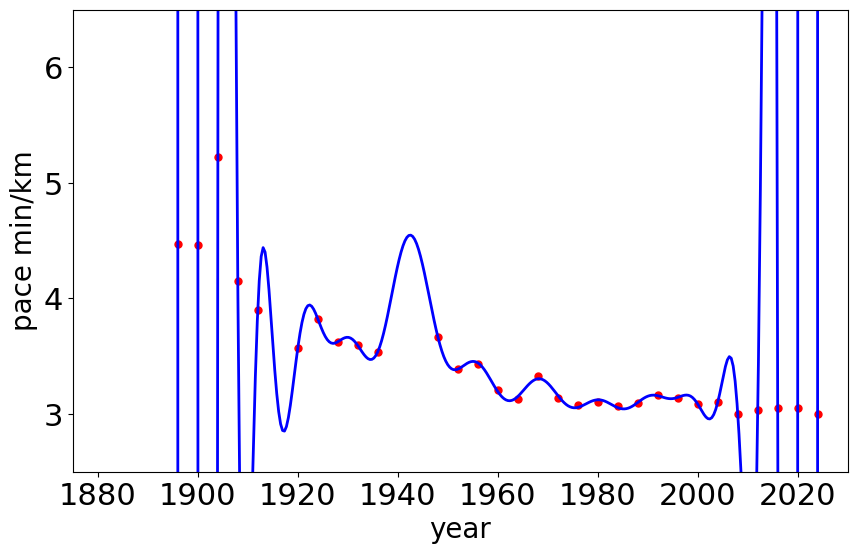

In [35]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-polynomial-29.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-polynomial-29.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 28-degree polynomial to the Olympic marathon
data.</i>

## Expected Loss

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/expected-loss.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/expected-loss.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Our objective function so far has been the negative log likelihood,
which we have minimized (via the sum of squares error) to obtain our
model. However, there is an alternative perspective on an objective
function, that of a *loss function*. A loss function is a cost function
associated with the penalty you might need to pay for a particular
incorrect decision. One approach to machine learning involves specifying
a loss function and considering how much a particular model is likely to
cost us across its lifetime. We can represent this with an expectation.
If our loss function is given as $L(y, x, \mathbf{ w})$ for a particular
model that predicts $y$ given $x$ and $\mathbf{ w}$ then we are
interested in minimizing the expected loss under the likely distribution
of $y$ and $x$. To understand this formally we define the *true*
distribution of the data samples, $y$, $x$. This is a particular
distribution that we don’t typically have access to. To represent it we
define a variant of the letter ‘P,’ $\mathbb{P}(y, x)$. If we genuinely
pay $L(y, x, \mathbf{ w})$ for every mistake we make, and the future
test data is genuinely drawn from $\mathbb{P}(y, x)$ then we can define
our expected loss, or risk, to be, $$
R(\mathbf{ w}) = \int L(y, x, \mathbf{ w}) \mathbb{P}(y, x) \text{d}y
\text{d}x.
$$ Of course, in practice, this value can’t be computed *but* it serves
as a reminder of what it is we are aiming to minimize and under certain
circumstances it can be approximated.

## Sample-Based Approximations

A sample-based approximation to an expectation involves replacing the
true expectation with a sum over samples from the distribution. $$
\int f(z) p(z) \text{d}z\approx \frac{1}{s}\sum_{i=1}^s f(z_i).
$$ if $\{z_i\}_{i=1}^s$ are a set of $s$ independent and identically
distributed samples from the distribution $p(z)$. This approximation
becomes better for larger $s$, although the *rate of convergence* to the
true integral will be very dependent on the distribution $p(z)$ *and*
the function $f(z)$.

That said, this means we can approximate our true integral with the sum,
$$
R(\mathbf{ w}) \approx \frac{1}{n}\sum_{i=1}^{n} L(y_i, x_i, \mathbf{ w}).
$$

if $y_i$ and $x_i$ are independent samples from the true distribution
$\mathbb{P}(y, x)$. Minimizing this sum directly is known as *empirical
risk minimization*. The sum of squares error we have been using can be
recovered for this case by considering a *squared loss*, $$
L(y, x, \mathbf{ w}) = (y-\mathbf{ w}^\top\boldsymbol{\phi}(x))^2,
$$ which gives an empirical risk of the form $$
R(\mathbf{ w}) \approx \frac{1}{n} \sum_{i=1}^{n}
(y_i - \mathbf{ w}^\top \boldsymbol{\phi}(x_i))^2
$$ which up to the constant $\frac{1}{n}$ is identical to the objective
function we have been using so far.

## Estimating Risk through Validation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/empirical-risk-minimization.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/empirical-risk-minimization.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Unfortuantely, minimising the empirial risk only guarantees something
about our performance on the training data. If we don’t have enough data
for the approximation to the risk to be valid, then we can end up
performing significantly worse on test data. Fortunately, we can also
estimate the risk for test data through estimating the risk for unseen
data. The main trick here is to ‘hold out’ a portion of our data from
training and use the models performance on that sub-set of the data as a
proxy for the true risk. This data is known as ‘validation’ data. It
contrasts with test data, because its values are known at the model
design time. However, in contrast to test date we don’t use it to fit
our model. This means that it doesn’t exhibit the same bias that the
empirical risk does when estimating the true risk.

## Validation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/validation-short-intro.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/validation-short-intro.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Next we will explore techniques for model selection that make use of
validation data. Data that isn’t seen by the model in the learning (or
fitting) phase, but is used to *validate* our choice of model from
amoungst the different designs we have selected.

In machine learning, we are looking to minimise the value of our
objective function $E$ with respect to its parameters $\mathbf{ w}$. We
do this by considering our training data. We minimize the value of the
objective function as it’s observed at each training point. However we
are really interested in how the model will perform on future data. For
evaluating that we choose to *hold out* a portion of the data for
evaluating the quality of the model.

We will review the different methods of model selection on the Olympics
marathon data.

## Validation on the Olympic Marathon Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-validation-fit.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-validation-fit.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

The first thing we’ll do is fit a standard linear model to the data. We
recall from previous lectures and lab classes that to do this we need to
solve the system $$
\boldsymbol{ \Phi}^\top \boldsymbol{ \Phi}\mathbf{ w}= \boldsymbol{ \Phi}^\top \mathbf{ y}
$$ for $\mathbf{ w}$ and use the resulting vector to make predictions at
the training points and test points, $$
\mathbf{ f}= \boldsymbol{ \Phi}\mathbf{ w}.
$$ The prediction function can be used to compute the objective
function, $$
E(\mathbf{ w}) = \sum_{i}^{n} (y_i - \mathbf{ w}^\top\phi(\mathbf{ y}_i))^2
$$ by substituting in the prediction in vector form we have $$
E(\mathbf{ w}) =  (\mathbf{ y}- \mathbf{ f})^\top(\mathbf{ y}- \mathbf{ f})
$$

### Exercise 1

In this question you will construct some flexible general code for
fitting linear models.

Create a python function that computes $\boldsymbol{ \Phi}$ for the
linear basis,
$$\boldsymbol{ \Phi}= \begin{bmatrix} \mathbf{ y}& \mathbf{1}\end{bmatrix}$$
Name your function `linear`. `Phi` should be in the form of a *design
matrix* and `x` should be in the form of a `numpy` two dimensional array
with $n$ rows and 1 column Calls to your function should be in the
following form:

`Phi = linear(x)`

Create a python function that accepts, as arguments, a python function
that defines a basis (like the one you’ve just created called `linear`)
as well as a set of inputs and a vector of parameters. Your new python
function should return a prediction. Name your function `prediction`.
The return value `f` should be a two dimensional `numpy` array with $n$
rows and $1$ column, where $n$ is the number of data points. Calls to
your function should be in the following form:

`f = prediction(w, x, linear)`

Create a python function that computes the sum of squares objective
function (or error function). It should accept your input data (or
covariates) and target data (or response variables) and your parameter
vector `w` as arguments. It should also accept a python function that
represents the basis. Calls to your function should be in the following
form:

`e = objective(w, x, y, linear)`

Create a function that solves the linear system for the set of
parameters that minimizes the sum of squares objective. It should accept
input data, target data and a python function for the basis as the
inputs. Calls to your function should be in the following form:

`w = fit(x, y, linear)`

Fit a linear model to the olympic data using these functions and plot
the resulting prediction between 1890 and 2020. Set the title of the
plot to be the error of the fit on the *training data*.

In [36]:
# Write your answer to Exercise 1 here






## Polynomial Fit: Training Error

### Exercise 2

In this question we extend the code above to a non- linear basis (a
quadratic function).

Start by creating a python-function called `quadratic`. It should
compute the quadratic basis. $$
\boldsymbol{ \Phi}= \begin{bmatrix} \mathbf{1} & \mathbf{ y}& \mathbf{ y}^2\end{bmatrix}
$$ It should be called in the following form:

`Phi = quadratic(x)`

Use this to compute the quadratic fit for the model, again plotting the
result titled by the error.

In [37]:
# Write your answer to Exercise 2 here






## Polynomial Fits to Olympics Data

In [38]:
import pods
import mlai

In [39]:
max_basis = 28
data_limits = (1888, 2030)
basis = mlai.Basis(mlai.polynomial, number=1, data_limits=data_limits)
num_data = x.shape[0]

In [40]:
import mlai.plot as plot

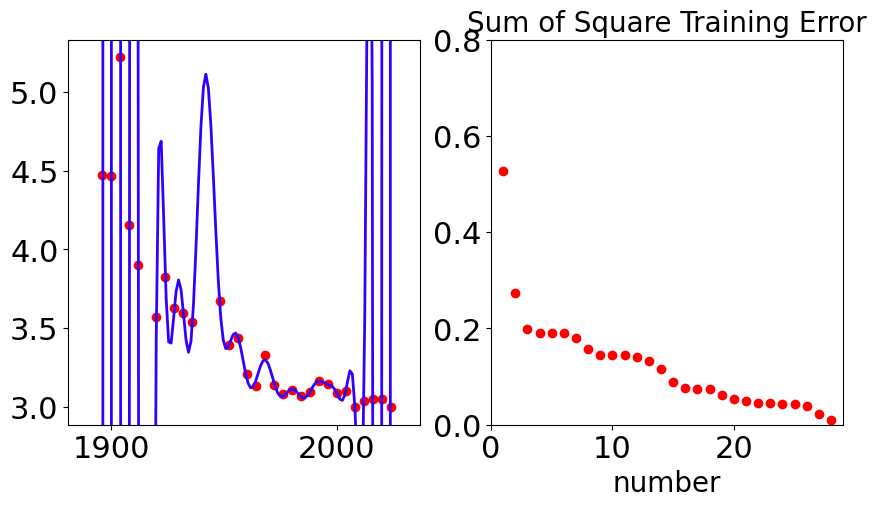

In [41]:
plot.rmse_fit(x, y, param_name='number', param_range=(1, max_basis+1), 
              model=mlai.LM, basis=basis, 
              xlim=data_limits, objective_ylim=[0, 0.8],
              diagrams='./ml')

In [42]:
from ipywidgets import IntSlider

In [43]:
import notutils as nu

In [44]:
nu.display_plots('olympic_LM_polynomial_number{num_basis:0>3}.svg', 
                            directory='./ml', 
                            num_basis=IntSlider(1, 1, max_basis, 1))

interactive(children=(IntSlider(value=1, description='num_basis', max=28, min=1), Output()), _dom_classes=('wi…

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic_LM_polynomial_number028.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Polynomial fit to olympic data with 28 basis functions.</i>

## Hold Out Validation on Olympic Marathon Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-hold-out-validation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-hold-out-validation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [45]:
import mlai.plot as plot
import mlai

In [46]:
data_limits=xlim
basis = mlai.Basis(mlai.polynomial, number=1, data_limits=data_limits)
max_basis = 11

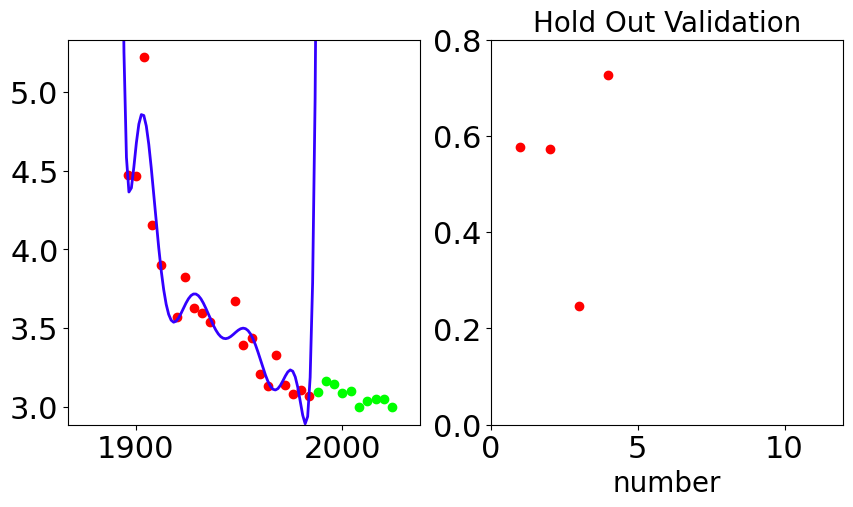

In [47]:
plot.holdout_fit(x, y, param_name='number', 
                 param_range=(1, max_basis+1), 
                 model=mlai.LM, basis=basis, 
                 permute=False, objective_ylim=[0, 0.8], 
                 xlim=data_limits, prefix='olympic_val_extra', 
                 diagrams='./ml')

In [48]:
import notutils as nu
from ipywidgets import IntSlider

In [49]:
import notutils as nu

In [50]:
nu.display_plots('olympic_val_extra_LM_polynomial_number{num_basis:0>3}.svg', 
                            directory='./ml', 
                            num_basis=IntSlider(1, 1, max_basis, 1))

interactive(children=(IntSlider(value=1, description='num_basis', max=11, min=1), Output()), _dom_classes=('wi…

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic_val_extra_LM_polynomial_number011.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Olympic marathon data with validation error for
extrapolation.</i>

## Extrapolation

## Interpolation

In [51]:
import mlai.plot as plot

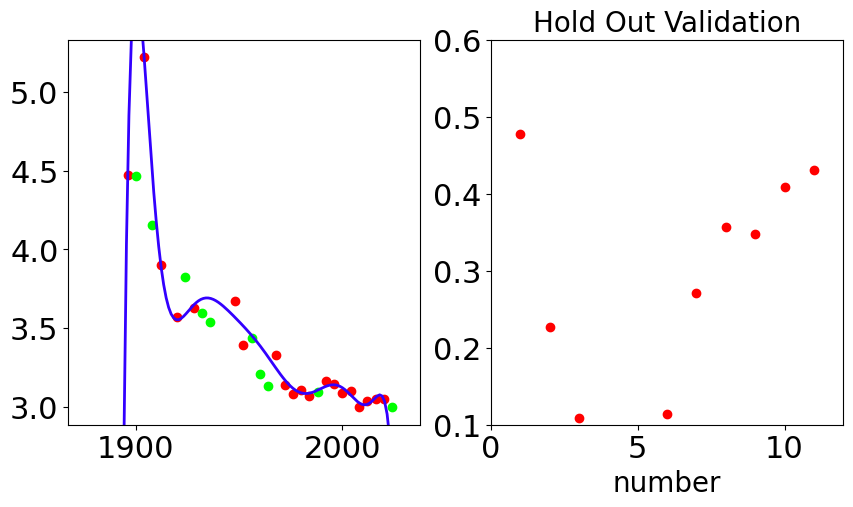

In [52]:
plot.holdout_fit(x, y, param_name='number', param_range=(1, max_basis+1), 
                 model=mlai.LM, basis=basis, 
                 xlim=data_limits, prefix='olympic_val_inter', 
                 objective_ylim=[0.1, 0.6], permute=True,
                 diagrams='./ml')

In [53]:
import notutils as nu
from ipywidgets import IntSlider

In [54]:
import notutils as nu

In [55]:
nu.display_plots('olympic_val_inter_LM_polynomial_number{num_basis:0>3}.svg', 
                            directory='./ml', 
                            num_basis=IntSlider(1, 1, max_basis, 1))

interactive(children=(IntSlider(value=1, description='num_basis', max=11, min=1), Output()), _dom_classes=('wi…

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic_val_inter_LM_polynomial_number011.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Olympic marathon data with validation error for
interpolation.</i>

## Choice of Validation Set

## Hold Out Data

You have a conclusion as to which model fits best under the training
error, but how do the two models perform in terms of validation? In this
section we consider *hold out* validation. In hold out validation we
remove a portion of the training data for *validating* the model on. The
remaining data is used for fitting the model (training). Because this is
a time series prediction, it makes sense for us to hold out data at the
end of the time series. This means that we are validating on future
predictions. We will hold out data from after 1980 and fit the model to
the data before 1980.

In [56]:
# select indices of data to 'hold out'
indices_hold_out = np.flatnonzero(x>1980)

# Create a training set
x_train = np.delete(x, indices_hold_out, axis=0)
y_train = np.delete(y, indices_hold_out, axis=0)

# Create a hold out set
x_valid = np.take(x, indices_hold_out, axis=0)
y_valid = np.take(y, indices_hold_out, axis=0)

### Exercise 3

For both the linear and quadratic models, fit the model to the data up
until 1980 and then compute the error on the held out data (from 1980
onwards). Which model performs better on the validation data?

In [57]:
# Write your answer to Exercise 3 here






## Richer Basis Set

Now we have an approach for deciding which model to retain, we can
consider the entire family of polynomial bases, with arbitrary degrees.

### Exercise 4

Now we are going to build a more sophisticated form of basis function,
one that can accept arguments to its inputs (similar to those we used in
[this lab](./week4.ipynb)). Here we will start with a polynomial basis.

    def polynomial(x, degree, loc, scale):
        degrees =np.arange(degree+1)
        return ((x-loc)/scale)**degrees

The basis as we’ve defined it has three arguments as well as the input.
The degree of the polynomial, the scale of the polynomial and the
offset. These arguments need to be passed to the basis functions
whenever they are called. Modify your code to pass these additional
arguments to the python function for creating the basis. Do this for
each of your functions `predict`, `fit` and `objective`. You will find
`*args` (or `**kwargs`) useful.

Write code that tries to fit different models to the data with
polynomial basis. Use a maximum degree for your basis from 0 to 17. For
each polynomial store the *hold out validation error* and the *training
error*. When you have finished the computation plot the hold out error
for your models and the training error for your p. When computing your
polynomial basis use `offset=1956.` and `scale=120.` to ensure that the
data is mapped (roughly) to the -1, 1 range.

Which polynomial has the minimum training error? Which polynomial has
the minimum validation error?

In [58]:
# Write your answer to Exercise 4 here






## Leave One Out Validation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-loo-validation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-loo-validation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [59]:
import mlai
import pods

In [60]:
data_limits=xlim
basis = mlai.Basis(mlai.polynomial, number=1, data_limits=data_limits)
max_basis = 11

In [61]:
import mlai.plot as plot

In [62]:
# The leave one out cross validation can be slow to run, so here it's commented.
#plot.loo_fit(x, y, param_name='number', param_range=(1, max_basis+1),  
#             model=mlai.LM, basis=basis, 
#             xlim=data_limits, objective_ylim=[0, 0.8], prefix='olympic_loo',
#            diagrams='./ml')

In [63]:
from ipywidgets import IntSlider
import pods

In [64]:
import notutils as nu

In [65]:
nu.display_plots('olympic_loo{part:0>3}_LM_polynomial_number{num_basis:0>3}.svg', 
                            directory='./ml', 
                            num_basis=IntSlider(1, 1, max_basis, 1), 
                            part=IntSlider(0, 0, x.shape[0], 1))

interactive(children=(IntSlider(value=1, description='num_basis', max=11, min=1), IntSlider(value=0, descripti…

Hold out validation uses a portion of the data to hold out and a portion
of the data to train on. There is always a compromise between how much
data to hold out and how much data to train on. The more data you hold
out, the better the estimate of your performance at ‘run-time’ (when the
model is used to make predictions in real applications). However, by
holding out more data, you leave less data to train on, so you have a
better validation, but a poorer quality model fit than you could have
had if you’d used all the data for training. Leave one out cross
validation leaves as much data in the training phase as possible: you
only take *one point* out for your validation set. However, if you do
this for hold-out validation, then the quality of your validation error
is very poor because you are testing the model quality on one point
only. In *cross validation* the approach is to improve this estimate by
doing more than one model fit. In *leave one out cross validation* you
fit $n$ different models, where $n$ is the number of your data. For each
model fit you take out one data point, and train the model on the
remaining $n-1$ data points. You validate the model on the data point
you’ve held out, but you do this $n$ times, once for each different
model. You then take the *average* of all the $n$ badly estimated hold
out validation errors. The average of this estimate is a good estimate
of performance of those models on the test data.

### Exercise 5

Write code that computes the *leave one out* validation error for the
olympic data and the polynomial basis. Use the functions you have
created above: `objective`, `fit`, `polynomial`. Compute the
*leave-one-out* cross validation error for basis functions containing a
maximum degree from 0 to 17.

In [66]:
# Write your answer to Exercise 5 here






## $k$-fold Cross Validation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-k-fold-validation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-k-fold-validation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [67]:
import mlai
import pods

In [68]:
data_limits=xlim
basis = mlai.Basis(mlai.polynomial, number=1, data_limits=data_limits)
max_basis = 11

In [69]:
import mlai.plot as plot

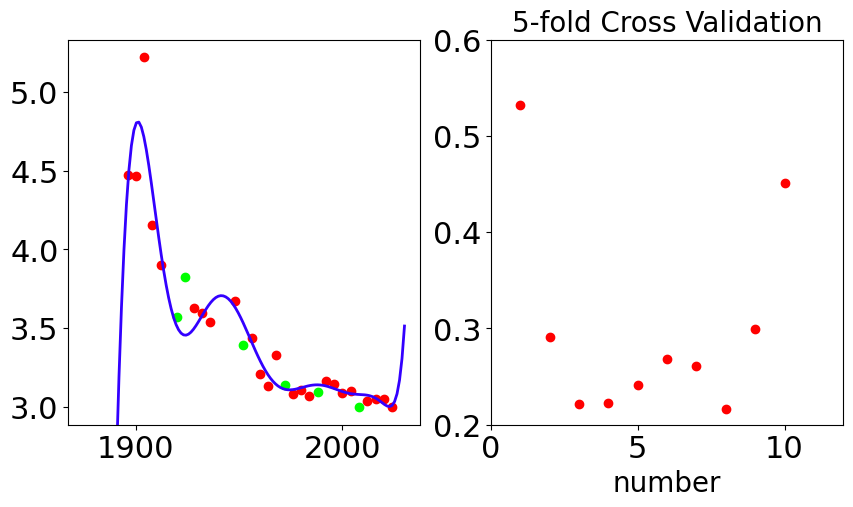

In [70]:
num_parts=5 # set k
plot.cv_fit(x, y, param_name='number', 
            param_range=(1, max_basis+1),
            model=mlai.LM, 
            basis=basis, 
            xlim=data_limits, 
            objective_ylim=[0.2,0.6], 
            num_parts=num_parts,
            diagrams='./ml')

In [71]:
from ipywidgets import IntSlider
import pods

In [72]:
import notutils as nu

In [73]:
nu.display_plots('olympic_{num_parts}'.format(num_parts=num_parts) + 'cv{part:0>2}_LM_polynomial_number{number:0>3}.svg', 
                            directory='./ml', 
                            part=IntSlider(0,0,5,1),
                            number=IntSlider(1, 1, max_basis, 1))

interactive(children=(IntSlider(value=0, description='part', max=5), IntSlider(value=1, description='number', …

Leave one out cross validation produces a very good estimate of the
performance at test time, and is particularly useful if you don’t have a
lot of data. In these cases you need to make as much use of your data
for model fitting as possible, and having a large hold out data set (to
validate model performance) can have a significant effect on the size of
the data set you have to fit your model, and correspondingly, the
complexity of the model you can fit. However, leave one out cross
validation involves fitting $n$ models, where $n$ is your number of
training data. For the olympics example, this is only 27 model fits, but
in practice many data sets consist thousands or millions of data points,
and fitting many millions of models for estimating validation error
isn’t really practical. One option is to return to *hold out*
validation, but another approach is to perform $k$-fold cross
validation. In $k$-fold cross validation you split your data into $k$
parts. Then you use $k-1$ of those parts for training, and hold out one
part for validation. Just like we did for the hold out validation above.
In *cross* validation, however, you repeat this process. You swap the
part of the data you just used for validation back in to the training
set and select another part for validation. You then fit the model to
the new training data and validate on the portion of data you’ve just
extracted. Each split of training/validation data is called a *fold* and
since you do this process $k$ times, the procedure is known as $k$-fold
cross validation. The term *cross* refers to the fact that you cross
over your validation portion back into the training data every time you
perform a fold.

### Exercise 6

Perform $k$-fold cross validation on the olympic data with your
polynomial basis. Use $k$ set to 5 (e.g. five fold cross validation). Do
the different forms of validation select different models? Does five
fold cross validation always select the same model?

*Note*: The data doesn’t divide into 5 equal size partitions for the
five fold cross validation error. Don’t worry about this too much. Two
of the partitions will have an extra data point. You might find
`np.random.permutation?` useful.

In [74]:
# Write your answer to Exercise 6 here






## The Bootstrap

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/the-bootstrap.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/the-bootstrap.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Bootstrap sampling (Efron, 1979) is an approach to assessing the
sensitivity of the model to different variations on a data set. In an
ideal world, we’d like to be able to look at different realisations from
the original data generating distribution $\mathbb{P}(y, \mathbf{ x})$,
but this is not available to us.

In bootstrap sampling, we take the sample we have, $$
\mathbf{ y}, \mathbf{X}\sim \mathbb{P}(y, \mathbf{ x})
$$ and resample from that data, rather than from the true distribution.
So, we have a new data set, $\hat{\mathbf{ y}}$, $\hat{\mathbf{X}}$
which is sampled from the original *with* replacement.

In [75]:
import numpy as np

In [76]:
def bootstrap(X):
    "Return a bootstrap sample from a data set."
    n = X.shape[0]
    ind = np.random.choice(n, n, replace=True) # Sample randomly with replacement.
    return X[ind, :]  

## Bootstrap and Olympic Marathon Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-bootstrap-polynomial.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/olympic-marathon-bootstrap-polynomial.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

First we define a function to bootstrap resample our dataset.

In [77]:
import numpy as np

In [78]:
def bootstrap(X, y):
    "Return a bootstrap sample from a data set."
    n = X.shape[0]
    ind = np.random.choice(n, n, replace=True) # Sample randomly with replacement.
    return X[ind, :], y[ind, :]

In [79]:
num_bootstraps = 10

In [80]:
def bootstrap_fit(Phi, y, size):
    W = np.zeros((Phi.shape[1], size))
    for i in range(size):
        Phi_hat, y_hat = bootstrap(Phi, y)
        W[:, i:i+1] = basis_fit(Phi_hat, y_hat)
    return W

## Linear Fit

In [81]:
poly_args = {'num_basis':2, # two basis functions (1 and x)
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
W_hat = bootstrap_fit(Phi, y, num_bootstraps)

Now we make some predictions for the fit.

In [82]:
x_pred = np.linspace(xlim[0], xlim[1], 400)[:, np.newaxis]
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@W_hat

In [83]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

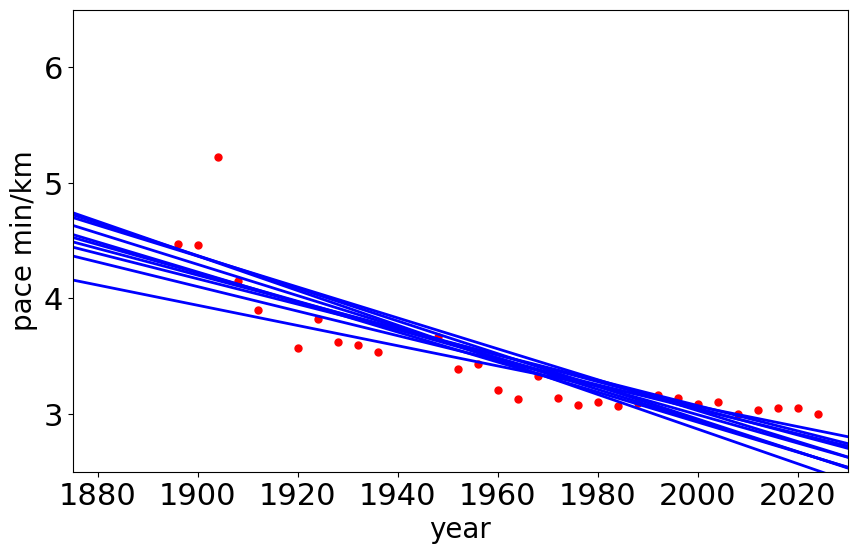

In [84]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-bootstrap-polynomial-2.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-bootstrap-polynomial-2.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 1 degree polynomial (a linear model) to the olympic
marathon data.</i>

## Cubic Fit

In [85]:
poly_args = {'num_basis':4, # four basis: 1, x, x^2, x^3
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
W_hat = bootstrap_fit(Phi, y, num_bootstraps)

In [86]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@W_hat

In [87]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

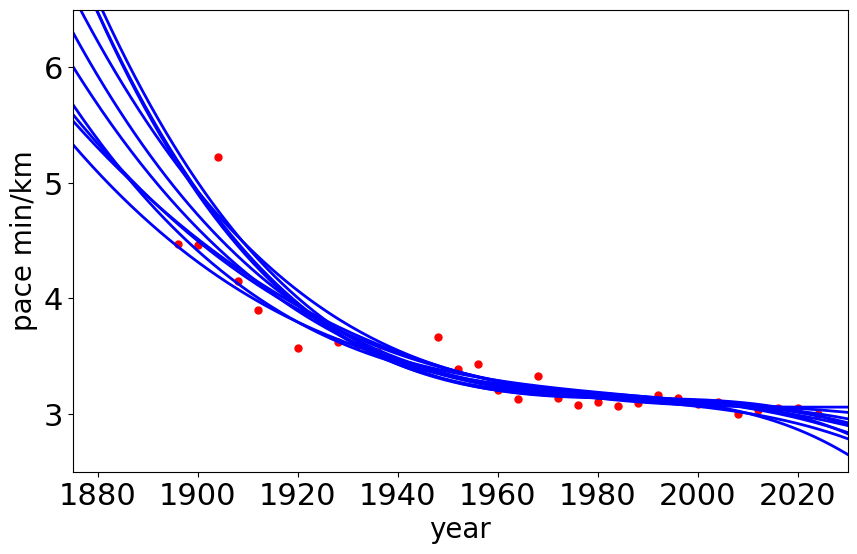

In [88]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-bootstrap-polynomial-4.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-bootstrap-polynomial-4.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 3 degree polynomial (a cubic model) to the olympic
marathon data.</i>

## 9th Degree Polynomial Fit

Now we’ll try a 9th degree polynomial fit to the data.

In [89]:
poly_args = {'num_basis':10, # basis up to x^9
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
W_hat = bootstrap_fit(Phi, y, num_bootstraps)

In [90]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@W_hat

In [91]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

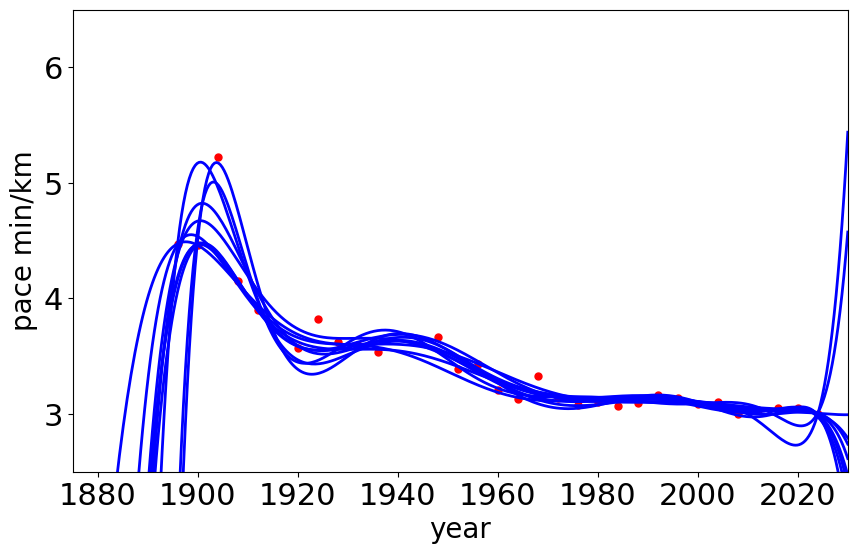

In [92]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-bootstrap-polynomial-10.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-bootstrap-polynomial-10.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 9 degree polynomial to the olympic marathon
data.</i>

## 16th Degree Polynomial Fit

Now we’ll try a 16th degree polynomial fit to the data.

In [93]:
poly_args = {'num_basis':17, # basis up to x^16
             'data_limits':xlim}
Phi = polynomial(x, **poly_args)
W_hat = bootstrap_fit(Phi, y, num_bootstraps)

In [94]:
Phi_pred = polynomial(x_pred, **poly_args)
f_pred = Phi_pred@W_hat

In [95]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

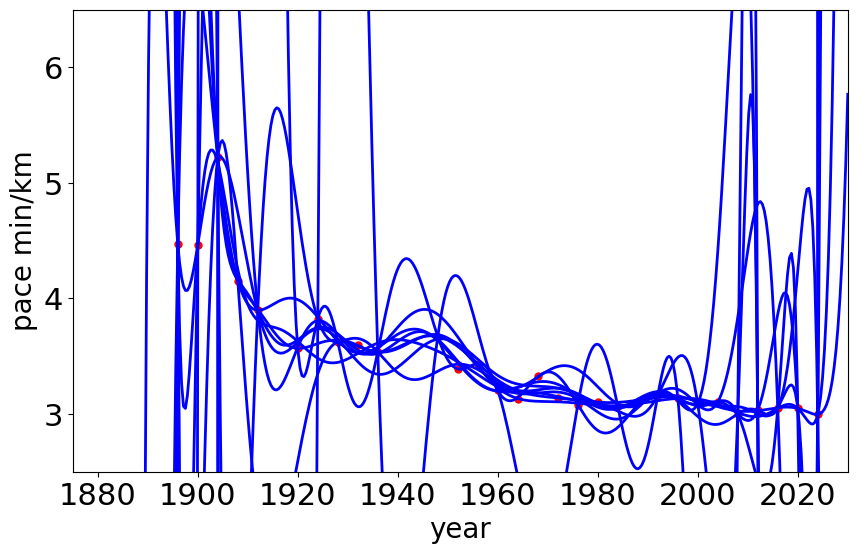

In [96]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
_ = ax.plot(x, y, 'r.',markersize=10)
ax.set_xlabel('year', fontsize=20)
ax.set_ylabel('pace min/km', fontsize=20)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

_ = ax.plot(x_pred, f_pred, 'b-', linewidth=2)

mlai.write_figure(filename='olympic-marathon-bootstrap-polynomial-17.svg', 
                  directory='./ml')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/olympic-marathon-bootstrap-polynomial-17.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Fit of a 16 degree polynomial to the olympic marathon
data.</i>

## Bias Variance Decomposition

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/bias-variance-dilemma.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/bias-variance-dilemma.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

One of Breiman’s ideas for improving predictive performance is known as
bagging (Breiman, 1996). The idea is to train a number of models on the
data such that they overfit (high variance). Then average the
predictions of these models. The models are trained on different
bootstrap samples (Efron, 1979) and their predictions are aggregated
giving us the acronym, Bagging. By combining decision trees with
bagging, we recover random forests (Breiman, 2001).

Bias and variance can also be estimated through Efron’s bootstrap
(Efron, 1979), and the traditional view has been that there’s a form of
Goldilocks effect, where the best predictions are given by the model
that is ‘just right’ for the amount of data available. Not to simple,
not too complex. The idea is that bias decreases with increasing model
complexity and variance increases with increasing model complexity.
Typically plots begin with the Mummy bear on the left (too much bias)
end with the Daddy bear on the right (too much variance) and show a dip
in the middle where the Baby bear (just) right finds themselves.

The Daddy bear is typically positioned at the point where the model can
exactly interpolate the data. For a generalized linear model (McCullagh
and Nelder, 1989), this is the point at which the number of parameters
is equal to the number of data[1].

The bias-variance decomposition (Geman et al., 1992) considers the
expected test error for different variations of the *training data*
sampled from, $\mathbb{P}(\mathbf{ x}, y)$ $$\begin{align*}
R(\mathbf{ w}) = & \int \left(y- f^*(\mathbf{ x})\right)^2 \mathbb{P}(y, \mathbf{ x}) \text{d}y\text{d}\mathbf{ x}\\
& \triangleq \mathbb{E}\left[ \left(y- f^*(\mathbf{ x})\right)^2 \right].
\end{align*}$$

This can be decomposed into two parts, $$
\begin{align*}
\mathbb{E}\left[ \left(y- f(\mathbf{ x})\right)^2 \right] = & \text{bias}\left[f^*(\mathbf{ x})\right]^2  + \text{variance}\left[f^*(\mathbf{ x})\right]  +\sigma^2,
\end{align*}
$$ where the bias is given by $$
  \text{bias}\left[f^*(\mathbf{ x})\right] =
\mathbb{E}\left[f^*(\mathbf{ x})\right] - f(\mathbf{ x})
$$ and it summarizes error that arises from the model’s inability to
represent the underlying complexity of the data. For example, if we were
to model the marathon pace of the winning runner from the Olympics by
computing the average pace across time, then that model would exhibit
*bias* error because the reality of Olympic marathon pace is it is
changing (typically getting faster).

The variance term is given by $$
  \text{variance}\left[f^*(\mathbf{ x})\right] = \mathbb{E}\left[\left(f^*(\mathbf{ x}) - \mathbb{E}\left[f^*(\mathbf{ x})\right]\right)^2\right].
  $$ The variance term is often described as arising from a model that
is too complex, but we must be careful with this idea. Is the model
really too complex relative to the real world that generates the data?
The real world is a complex place, and it is rare that we are
constructing mathematical models that are more complex than the world
around us. Rather, the ‘too complex’ refers to ability to estimate the
parameters of the model given the data we have. Slight variations in the
training set cause changes in prediction.

Models that exhibit high variance are sometimes said to ‘overfit’ the
data whereas models that exhibit high bias are sometimes described as
‘underfitting’ the data.

[1] Assuming we are ignoring parameters in the link function and the
distribution function.

## No Free Lunch Theorem

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/no-free-lunch-theorem.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/no-free-lunch-theorem.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Also related on generalisation error is the so called ‘no free lunch
theorem,’ which refers to our inability to decide what a better learning
algorithm is without making assumptions about the data (Wolpert, 1996)
(see also Wolpert (2002)).

## Regularisation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/linear-regression-regularisation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/linear-regression-regularisation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

The solution to the linear system is given by solving, $$
\boldsymbol{ \Phi}^\top\boldsymbol{ \Phi}\mathbf{ w}= \boldsymbol{ \Phi}^\top\mathbf{ y}
$$ for $\mathbf{ w}$.

But if $\boldsymbol{ \Phi}^\top\boldsymbol{ \Phi}$ is not full rank,
this system cannot be solved. This is reflective of an *underdetermined
system* of equations. There are *infinite* solutions. This happens when
there are more basis functions than data points, in effect the number of
data we have is not enough to determine the parameters.

Thinking about this in terms of the Hessian, if
$\boldsymbol{ \Phi}^\top\boldsymbol{ \Phi}$ is not full rank, then we
are no longer at a minimum. We are in a trough, because *not full rank*
implies that there are fewer eigenvectors than dimensions, in effect for
those dimensions where there is no eigenvector, the objective function
is ‘flat.’ It is ambivalent to changes in parameters. This implies there
are infinite valid solutions.

One solution to this problem is to regularise the system.

## Coefficient Shrinkage

Coefficient shrinkage is a technique where the parameters of the of the
model are ‘encouraged’ to be small. In practice this is normally done by
augmenting the objective function with a term that keeps the parameters
low, typically by penalizing a norm.

## Tikhonov Regularisation

In neural network models this approach is sometimes called ‘weight
decay.’ At every gradient step we reduce the value of the weight a
little. This idea comes from an approach called Tikhonov regularization
(Tikhonov and Arsenin, 1977), where the objective function is augmented
by the L2 norm of the weights, $$
L(\mathbf{ w}) = (\mathbf{ y}- \mathbf{ f})^\top(\mathbf{ y}- \mathbf{ f}) + \alpha\left\Vert \mathbf{W} \right\Vert_2^2
$$ with some weighting $\alpha >0$. This has the effect of changing the
Hessian at the minimum to $$
\boldsymbol{ \Phi}^\top\boldsymbol{ \Phi}+ \alpha \mathbf{I}
$$ Which is always full rank. The minimal eigenvalues are now given by
$\alpha$.

## Lasso

Other techniques for regularization based on a norm of the parameters
include the Lasso (Tibshirani, 1996), which is an L1 norm of the
parameters

## Splines, Functions, Hilbert Kernels

Regularisation of the parameters has the desired effect of making the
solution viable, but it can sometimes be difficult to interpret,
particularly if the parameters don’t have any inherent meaning (like in
a neural network). An alternative approach is to regularize the
function, $\mathbf{ f}$, directly, (see e.g., Kimeldorf and Wahba (1970)
and Wahba (1990)). This is the approach taken by *spline models* which
use energy-based regularisation for $f(\cdot)$ and also *kernel methods*
such as the support vector machine (Schölkopf and Smola, 2001).

## Training with Noise

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/training-with-noise-tikhonov-regularisation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/training-with-noise-tikhonov-regularisation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In practice, and across the last two waves of neural networks, other
techniques for regularization have been used which can be seen as
perturbing the neural network in some way. For example, in dropout
(Srivastava et al., 2014), different basis functions are eliminated from
the gradient computation at each gradient update.

Many of these perturbations have some form of regularizing effect. The
exact nature of the effect is not always easy to characterize, but in
some cases, we can assess how these manipulations effect the model. For
example, Bishop (1995) analyzed training with ‘noisy inputs’ and showed
conditions under which it’s equivalent to Tikhonov regularization.

But in general, these approaches can have different interpretations and
they’ve also been related to ensemble learning (e.g. related to
*bagging* or Bayesian approaches).

## Thanks!

For more information on these subjects and more you might want to check
the following resources.

-   company: [Trent AI](https://trent.ai)
-   book: [The Atomic
    Human](https://www.penguin.co.uk/books/455130/the-atomic-human-by-lawrence-neil-d/9780241625248)
-   twitter: [@lawrennd](https://twitter.com/lawrennd)
-   podcast: [The Talking Machines](http://thetalkingmachines.com)
-   newspaper: [Guardian Profile
    Page](http://www.theguardian.com/profile/neil-lawrence)
-   blog:
    [http://inverseprobability.com](http://inverseprobability.com/blog.html)

::: {.cell .markdown}

## References

Bishop, C.M., 1995. Training with noise is equivalent to Tikhonov
regularization. Neural Computation 7, 108–116.
<https://doi.org/10.1162/neco.1995.7.1.108>

Breiman, L., 2001. Random forests. Mach. Learn. 45, 5–32.
<https://doi.org/10.1023/A:1010933404324>

Breiman, L., 1996. Bagging predictors. Machine Learning 24, 123–140.
<https://doi.org/10.1007/BF00058655>

Efron, B., 1979. Bootstrap methods: Another look at the jackkife. Annals
of Statistics 7, 1–26.

Geman, S., Bienenstock, E., Doursat, R., 1992. Neural networks and the
bias/variance dilemma. Neural Computation 4, 1–58.
<https://doi.org/10.1162/neco.1992.4.1.1>

Kimeldorf, G.S., Wahba, G., 1970. A correspondence between Bayesian
estimation of stochastic processes and smoothing by splines. Annals of
Mathematical Statistics 41, 495–502.

McCullagh, P., Nelder, J.A., 1989. Generalized linear models, 2nd ed.
Chapman; Hall.

Schölkopf, B., Smola, A.J., 2001. Learning with kernels. mit, Cambridge,
MA.

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I.,
Salakhutdinov, R., 2014. Dropout: A simple way to prevent neural
networks from overfitting. Journal of Machine Learning Research 15,
1929–1958.

Tibshirani, R., 1996. Regression shrinkage and selection via the lasso.
Journal of the Royal Statistical Society. Series B (Methodological) 58,
267–288.

Tikhonov, A.N., Arsenin, V.Y., 1977. Solutions of ill-posed problems. V.
H. Winston, Washington, DC.

Wahba, G., 1990. Spline models for observational data, First. ed. SIAM.
<https://doi.org/10.1137/1.9781611970128>

Wolpert, D.H., 2002. The supervised learning no-free-lunch theorems, in:
Roy, R., Köppen, M., Ovaska, S., Furuhashi, T., Hoffmann, F. (Eds.),
Soft Computing and Industry. Springer, London, pp. 25–.
<https://doi.org/10.1007/978-1-4471-0123-9_3>

Wolpert, D.H., 1996. The lack of a priori distinctions between learning
algorithms. Neural Computation 8.
<https://doi.org/10.1162/neco.1996.8.7.1341>